# 07 — Performance Benchmark of the Locked Champion

Measures **how fast and how efficiently** the locked LightGBM / RAW / F4 price model runs in-process:
load cost, single-row latency, batch throughput, scaling, memory and robustness.

| | |
|---|---|
| **Objective** | Establish an empirical in-process runtime baseline (no arbitrary SLA). |
| **Input** | Locked champion artifact + canonical Silver (target-free population) |
| **Output** | Benchmark tables and charts; run files are written only by section 19 (`skip-execution`) |
| **Out of scope** | Training, tuning, model comparison, network/HTTP/serving overhead |

Timings depend on the machine that ran this notebook (see section 02).

## Where this notebook sits

```mermaid
flowchart LR
    BR[("Bronze snapshot<br/>Parquet")] --> NB01 & NB02
    NB02 --> SV[("Silver<br/>rental_listings.parquet")]
    SV --> NB03 --> NB04 --> CH[("Locked champion<br/>LightGBM F4 RAW")]
    SV --> NB05
    CH --> NB06 & NB07
    NB01["01 · Raw EDA"]
    NB02["02 · Bronze → Silver"]
    NB03["03 · Feature contract"]
    NB04["04 · Price model"]
    NB05["05 · Nearby search"]
    NB06["06 · Shadow validation"]
    NB07["07 · Performance"]
    classDef current fill:#2a78d6,color:#ffffff,stroke:#184f95
    class NB07 current
```

The highlighted step is this notebook.

## 01. Purpose and Frozen Champion Contract

```mermaid
flowchart LR
    N4["04 Modeling<br/>locks the champion"] --> N6["06 Shadow validation<br/>model quality & drift"]
    N4 --> N7["07 Performance<br/>runtime & efficiency"]
```

- **Champion:** LightGBM Regressor · RAW target · F4 = `area_value_clean`, `source_code`, `ward_current`,
  `district_text_extracted`.
- **Target-free inference:** the actual rent is never an input.
- **No SLA assumed:** the goal is to measure and record a baseline, not to pass a threshold.

## 02. Benchmark Environment

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = next(
    p
    for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "crawler").is_dir() and (p / "analytics").is_dir()
)
sys.path.insert(0, str(PROJECT_ROOT))

from notebooks.utils import setup_project_path

PROJECT_ROOT = setup_project_path()

import json
import os
from datetime import datetime, timezone

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
from IPython.display import Markdown, display

from analytics.duckdb.connection import resolve_runtime_path
from roombeacon_crawler.config.get_env import env
from notebooks.utils.notebook_style import (
    CATEGORICAL,
    NEUTRAL,
    apply_style,
    bar_chart,
    compact_number,
)
from notebooks.utils.performance_benchmark import (
    BENCHMARK_RANDOM_SEED,
    PERF_BENCHMARK_DIR_NAME,
    build_performance_scorecard,
    compute_throughput,
    get_benchmark_environment,
    get_champion_quality_context,
    get_process_memory_mb,
    make_performance_run_id,
    persist_performance_run,
    run_base_benchmark,
    run_cold_vs_warm_benchmark,
    run_concurrency_benchmark,
    run_memory_stability_check,
    run_pipeline_stage_breakdown,
    run_repeated_stability_benchmark,
    run_robustness_benchmark,
    run_scaling_benchmark,
    run_standard_benchmark,
)
from notebooks.utils.shadow_validation import (
    file_sha256,
    prepare_shadow_population,
    resolve_champion_artifact,
)

np.random.seed(BENCHMARK_RANDOM_SEED)
apply_style()
BENCHMARK_DIR = PROJECT_ROOT / "data" / "modeling" / "roombeacon_price_benchmark_v3"
SILVER_PATH = resolve_runtime_path(env.processing.silver_dir) / "rental_listings.parquet"
PERF_OUTPUT_ROOT = PROJECT_ROOT / "data" / "modeling" / PERF_BENCHMARK_DIR_NAME

env_info = get_benchmark_environment()
display(
    pd.Series(
        {
            "OS": f"{env_info['os']} ({env_info['os_release']})",
            "Processor": env_info["processor"],
            "Cores (logical / physical)": f"{env_info['logical_cpus']} / {env_info['physical_cpus']}",
            "RAM (total / available)": f"{env_info['total_ram_gb']} GB / {env_info['available_ram_gb']} GB",
            "Python / LightGBM / pandas": f"{env_info['packages']['python']} / {env_info['packages']['lightgbm']} / {env_info['packages']['pandas']}",
            "Environment fingerprint": env_info["environment_fingerprint"],
            "Initial process RSS": f"{get_process_memory_mb():.1f} MB",
        },
        name="value",
    ).to_frame()
)

Đã phát hiện thư mục gốc của dự án RoomBeacon: /data/projects/roombeacon/source/roombeacon-system


,value
OS,Linux (7.0.0-38-generic)
Processor,x86_64
Cores (logical / physical),12 / 6
RAM (total / available),15.37 GB / 2.22 GB
Python / LightGBM / pandas,3.12.3 / 4.7.0 / 3.0.6
Environment fingerprint,b81afa87e1c7b210
Initial process RSS,225.1 MB


## 03. Load and Verify Champion Artifact

In [2]:
champion = resolve_champion_artifact(BENCHMARK_DIR)
assert champion.metadata["model_family"] == "LightGBM Regressor"
assert champion.metadata["target_transform"] == "RAW"
assert champion.metadata["feature_names"] == [
    "area_value_clean",
    "source_code",
    "ward_current",
    "district_text_extracted",
]
assert file_sha256(champion.artifact_path) == champion.metadata["artifact_sha256"]
display(
    pd.Series(
        {
            "Model ID": champion.metadata["model_id"],
            "Hyperparameters": json.dumps(champion.metadata["hyperparameters"], sort_keys=True),
            "Artifact": f"{champion.artifact_path.relative_to(PROJECT_ROOT)} ({champion.artifact_path.stat().st_size / 1024:.1f} KB)",
            "Artifact SHA-256": champion.metadata["artifact_sha256"],
            "Integrity": "PASS (hash and contract verified)",
        },
        name="locked champion",
    ).to_frame()
)

,locked champion
Model ID,roombeacon-price-lgbm-f4-raw-4c203abb3b62
Hyperparameters,"{""learning_rate"": 0.05, ""min_child_samples"": 3..."
Artifact,data/modeling/roombeacon_price_benchmark_v3/ch...
Artifact SHA-256,4c203abb3b6286fdf1846dec1a3c5af985fccaa44ae63a...
Integrity,PASS (hash and contract verified)


## 04. Build Target-Free Benchmark Population

In [3]:
with duckdb.connect(":memory:") as con:
    silver_df = con.execute("SELECT * FROM read_parquet(?)", [str(SILVER_PATH)]).df()
assert len(silver_df) == silver_df.rental_post_id.nunique(), "Silver rental_post_id must be unique"

population = prepare_shadow_population(silver_df, champion.metadata, policy="PERMISSIVE")
ready_population = population.ready_rows
display(
    pd.Series(
        {
            "Silver listings": f"{len(silver_df):,}",
            "Inference-ready": f"{len(ready_population):,}",
            "Coverage": f"{len(ready_population) / len(silver_df):.2%}",
            "Target used as feature": "No",
        },
        name="value",
    ).to_frame()
)

,value
Silver listings,"132,494"
Inference-ready,"129,112"
Coverage,97.45%
Target used as feature,No


## 05. Benchmark Methodology

| Level | What it measures |
|---|---|
| **BASE** | Artifact loading, basic memory, single-row and small-batch correctness with sanity checks |
| **STANDARD** | Hot inference path for 1 / 100 / 1,000 / 10,000 / all rows with `perf_counter_ns`; P50–P99, mean, std |
| **ADVANCED** | Cold vs warm, scaling, 7-stage pipeline, memory over repeated cycles, repeat stability, edge cases, threads |

**Hot inference path** = inference-ready rows → F4 matrix → `predict` → inverse target. Workloads are
sampled with `BENCHMARK_RANDOM_SEED = 42`.

## 06. BASE Benchmark

In [4]:
base_results = run_base_benchmark(
    champion, ready_population, sizes=(1, 100, 1000), seed=BENCHMARK_RANDOM_SEED
)
display(base_results)
assert (base_results["Sanity"] == "PASS").all(), "BASE predictions must pass sanity verification"

,Workload,Rows,Feature Prep ms,Predict ms,End-to-End ms,Throughput (rows/s),RSS Before MB,RSS Delta MB,Sanity
0,1 row,1,4.207,7.781,11.988,83.4,1340.51,0.008,PASS
1,100 rows,100,4.006,11.795,15.801,6328.9,1340.59,0.000,PASS
2,"1,000 rows",1000,5.955,7.402,13.357,74867.3,1341.38,0.000,PASS


## 07. STANDARD Benchmark

> **Why:** separate single-row latency (what one request feels) from batch throughput (what a nightly job gets). Amortized batch speed must never be quoted as single-row latency.

In [5]:
standard_results = run_standard_benchmark(
    champion, ready_population, workloads=(1, 100, 1000, 10000, None), seed=BENCHMARK_RANDOM_SEED
)
display(standard_results)

single_p50 = standard_results.loc[0, "Hot Path P50 ms"]
single_p95 = standard_results.loc[0, "Hot Path P95 ms"]
batch_rows = standard_results.loc[4, "Rows"]
batch_p50 = standard_results.loc[4, "Hot Path P50 ms"]
batch_thr = standard_results.loc[4, "Hot Path Throughput (rows/s)"]
batch_unit = standard_results.loc[4, "Hot Path ms / 1,000 rows"]
display(
    Markdown(
        f"""
- **Single row:** median **{single_p50:.2f} ms** (P95 {single_p95:.2f} ms) — warm in-process scoring including pandas
  frame creation; excludes network, HTTP framework, serialization, auth, queueing and database access.
- **Full batch ({batch_rows:,} rows):** median **{batch_p50:.1f} ms** → **{batch_thr:,.0f} rows/s** ({batch_unit:.3f} ms per 1,000 rows).
"""
    )
)

,Workload,Rows,Runs,Sample Hash,Hot Path P50 ms,Hot Path P90 ms,Hot Path P95 ms,Hot Path P99 ms,Hot Path Mean ms,Hot Path Std ms,P50 Predict ms,P50 Prep ms,Hot Path Throughput (rows/s),"Hot Path ms / 1,000 rows",RSS Before MB,RSS Delta MB
0,1 row,1,50,0ea23522b2c7cadb,7.900,13.378,16.366,19.656,8.792,3.390,4.198,3.401,126.6,7899.9560,1341.40,0.109
1,100 rows,100,30,f2a9cc197173a3aa,13.546,21.606,24.202,25.670,14.136,5.748,8.516,5.732,7382.0,135.4648,1341.63,0.023
2,"1,000 rows",1000,15,50eebf9ff711af6f,15.217,23.657,25.504,28.855,16.561,5.538,8.480,6.074,65716.0,15.2170,1341.75,0.000
3,"10,000 rows",10000,5,c7dacfe60b05028d,53.172,59.209,61.107,62.625,51.710,8.073,30.213,17.140,188067.8,5.3172,1344.51,0.000
4,Full population,129112,3,5f1944c4aa7ef3f7,315.442,320.907,321.590,322.136,306.301,22.014,223.600,78.096,409305.3,2.4432,1348.20,0.012



- **Single row:** median **7.90 ms** (P95 16.37 ms) — warm in-process scoring including pandas
  frame creation; excludes network, HTTP framework, serialization, auth, queueing and database access.
- **Full batch (129,112 rows):** median **315.4 ms** → **409,305 rows/s** (2.443 ms per 1,000 rows).


## 08. ADVANCED Benchmark

The following sections stress cold starts, scaling, stages, memory, repeatability, edge cases and concurrency.

## 09. Cold vs Warm Inference

> Cold model load = resolve + `joblib` deserialize + prepare + predict inside an already-running interpreter. It does **not** include process/container start or server bootstrap.

,Workload,Rows,Cold Model Load P50 ms,Warm Hot Path P50 ms,Cold Load Overhead ms,Cold Load / Warm Ratio
0,1 row,1,14.26,9.18,5.07,1.55
1,100 rows,100,27.77,12.98,14.79,2.14
2,"1,000 rows",1000,18.18,13.67,4.51,1.33
3,"10,000 rows",10000,47.12,41.75,5.36,1.13


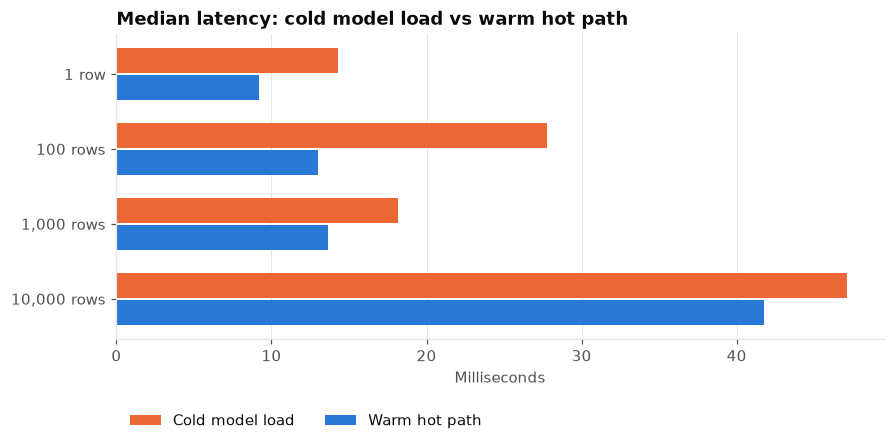

In [6]:
cold_warm_results = run_cold_vs_warm_benchmark(
    BENCHMARK_DIR,
    ready_population,
    sizes=(1, 100, 1000, 10000),
    repetitions=3,
    seed=BENCHMARK_RANDOM_SEED,
)
display(cold_warm_results)

fig, ax = plt.subplots(figsize=(9, 3.6))
positions = np.arange(len(cold_warm_results))
ax.barh(
    positions - 0.18,
    cold_warm_results["Cold Model Load P50 ms"],
    height=0.34,
    color=CATEGORICAL[1],
    label="Cold model load",
)
ax.barh(
    positions + 0.18,
    cold_warm_results["Warm Hot Path P50 ms"],
    height=0.34,
    color=CATEGORICAL[0],
    label="Warm hot path",
)
ax.set_yticks(positions, cold_warm_results["Workload"])
ax.invert_yaxis()
ax.set(title="Median latency: cold model load vs warm hot path", xlabel="Milliseconds")
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.2), ncol=2)
plt.show()

## 10. Batch Scaling

> **Why:** latency grows much slower than batch size, so batching cuts the cost per row.

,Rows,Workload,Median Hot Path ms,P95 Hot Path ms,Hot Path Throughput (rows/s),RSS MB
0,1,1,9.312,20.327,107.4,1353.10
1,10,10,7.374,11.223,1356.0,1353.10
2,100,100,7.855,12.366,12730.8,1353.10
3,1000,"1,000",10.402,13.535,96134.3,1353.10
4,10000,"10,000",42.415,48.830,235763.5,1353.11
5,129112,Full,274.498,283.238,470356.1,1353.12


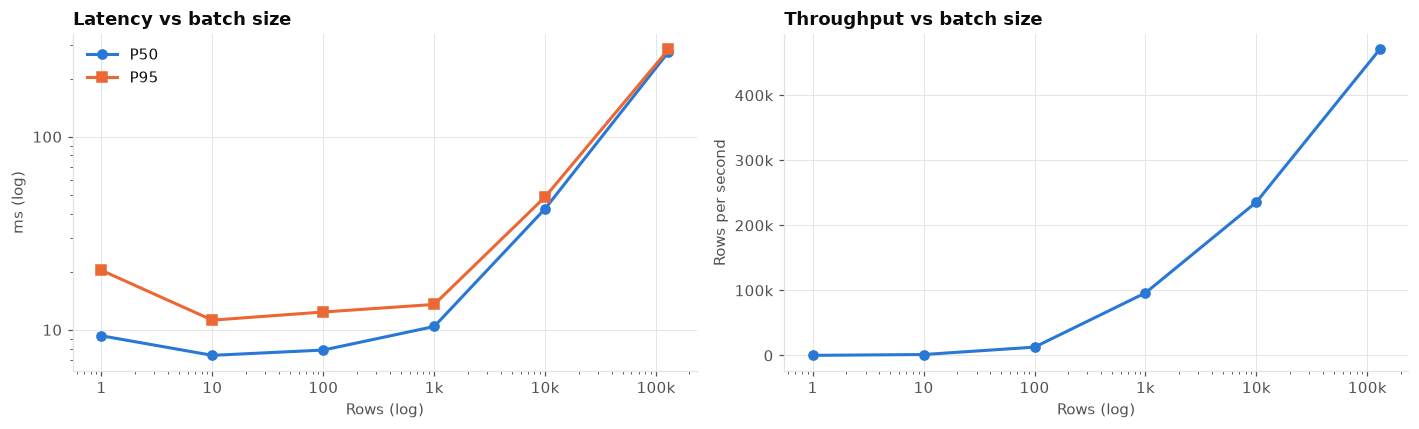

In [7]:
scaling_results = run_scaling_benchmark(
    champion, ready_population, sizes=(1, 10, 100, 1000, 10000, None), seed=BENCHMARK_RANDOM_SEED
)
display(scaling_results)

fig, (left, right) = plt.subplots(1, 2, figsize=(13, 4))
left.plot(
    scaling_results["Rows"],
    scaling_results["Median Hot Path ms"],
    marker="o",
    color=CATEGORICAL[0],
    label="P50",
)
left.plot(
    scaling_results["Rows"],
    scaling_results["P95 Hot Path ms"],
    marker="s",
    color=CATEGORICAL[1],
    label="P95",
)
left.set(
    xscale="log",
    yscale="log",
    title="Latency vs batch size",
    xlabel="Rows (log)",
    ylabel="ms (log)",
)
left.grid(axis="y")
left.legend(loc="upper left")
right.plot(
    scaling_results["Rows"],
    scaling_results["Hot Path Throughput (rows/s)"],
    marker="o",
    color=CATEGORICAL[0],
)
right.set(
    xscale="log", title="Throughput vs batch size", xlabel="Rows (log)", ylabel="Rows per second"
)
right.yaxis.set_major_formatter(plt.FuncFormatter(compact_number))
for axis in (left.xaxis, left.yaxis, right.xaxis):
    axis.set_major_formatter(plt.FuncFormatter(compact_number))
    axis.set_minor_formatter(plt.NullFormatter())
right.grid(axis="y")
plt.tight_layout()
plt.show()

## 11. Pipeline Stage Breakdown

> **Why:** find which of the 7 stages (from raw Silver rows to checked predictions) costs the most.

,Stage,Median ms,P95 ms,Min ms,Max ms,Share of Full Pipeline %
0,1. Input selection,20.283,26.926,11.529,27.714,18.06
1,2. Schema validation,4.327,5.855,3.929,6.102,3.85
2,3. Inference eligibility,49.349,59.625,30.998,61.834,43.94
3,4. F4 feature construction,1.342,1.768,1.142,1.828,1.19
4,5. Categorical preparation,10.667,14.029,8.752,15.988,9.50
5,6. LightGBM predict,25.541,29.208,16.455,29.665,22.74
6,7. Prediction sanity & post-processing,0.806,1.080,0.751,1.191,0.72


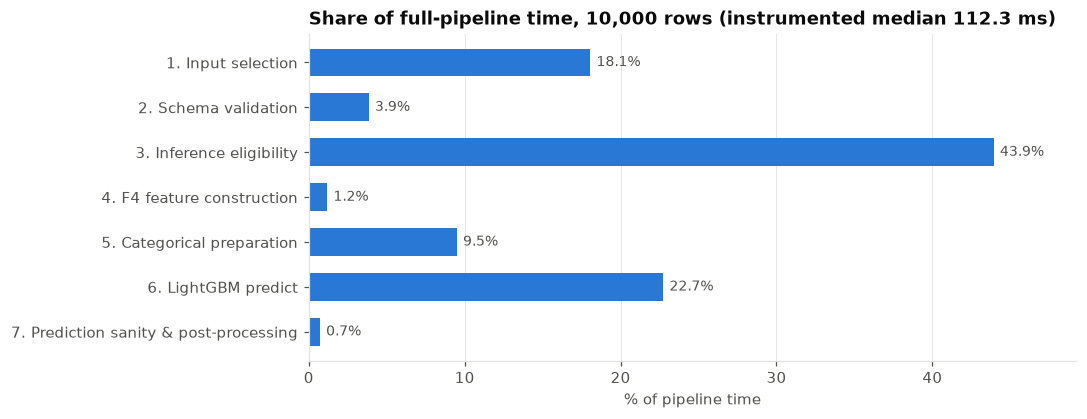

The full pipeline (~112.3 ms) is slower than the hot path (~53.2 ms P50) because it also selects input, validates the schema and evaluates target-free eligibility. The two scopes are timed separately, so their ~59.1 ms gap is a descriptive comparison rather than an exact additive decomposition.

In [8]:
stage_breakdown = run_pipeline_stage_breakdown(
    champion, silver_df, sample_size=10000, repetitions=10, seed=BENCHMARK_RANDOM_SEED
)
display(stage_breakdown)
full_pipeline_instrumented_median = float(stage_breakdown["Median ms"].sum())
hot_path_10k_p50 = float(standard_results.loc[3, "Hot Path P50 ms"])

bar_chart(
    stage_breakdown.set_index("Stage")["Share of Full Pipeline %"],
    sort=False,
    fmt="{:.1f}%",
    title=f"Share of full-pipeline time, 10,000 rows (instrumented median {full_pipeline_instrumented_median:.1f} ms)",
    xlabel="% of pipeline time",
)
plt.show()
display(
    Markdown(
        f"The full pipeline (~{full_pipeline_instrumented_median:.1f} ms) is slower than the hot path (~{hot_path_10k_p50:.1f} ms P50) "
        "because it also selects input, validates the schema and evaluates target-free eligibility. The two scopes are timed "
        f"separately, so their ~{full_pipeline_instrumented_median - hot_path_10k_p50:.1f} ms gap "
        "is a descriptive comparison rather than an exact additive decomposition."
    )
)

## 12. Memory Profile

> **Why:** a leak would show as RSS climbing cycle after cycle.

,Cycle,Stage,RSS MB,Delta from Initial MB
0,0,Initial State,1355.84,0.00
1,1,Cycle 1,1355.85,0.00
2,2,Cycle 2,1355.85,0.01
3,3,Cycle 3,1355.86,0.02
4,4,Cycle 4,1355.86,0.02
5,5,Cycle 5,1355.87,0.02
6,6,Cycle 6,1355.87,0.03
7,7,Cycle 7,1355.87,0.03
8,8,Cycle 8,1355.88,0.03
9,9,Cycle 9,1355.88,0.04


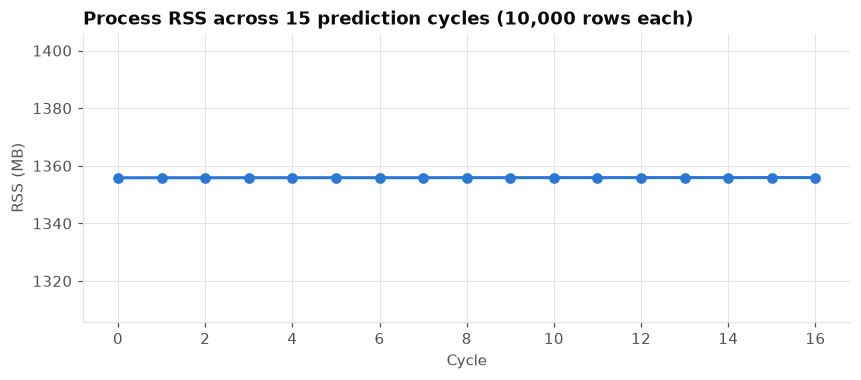

No material persistent RSS growth was observed across the measured repeated-run window.

In [9]:
mem_stability = run_memory_stability_check(
    champion, ready_population, sample_size=10000, cycles=15, seed=BENCHMARK_RANDOM_SEED
)
display(mem_stability)

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(mem_stability["Cycle"], mem_stability["RSS MB"], marker="o", color=CATEGORICAL[0])
rss_mid = mem_stability["RSS MB"].median()
ax.set_ylim(
    rss_mid - 50, rss_mid + 50
)  # ±50 MB window: shows flatness without magnifying sub-MB noise
ax.ticklabel_format(axis="y", useOffset=False)
ax.set(
    title="Process RSS across 15 prediction cycles (10,000 rows each)",
    xlabel="Cycle",
    ylabel="RSS (MB)",
)
ax.grid(axis="y")
plt.show()
display(
    Markdown(
        "No material persistent RSS growth was observed across the measured repeated-run window."
    )
)

## 13. CPU / Runtime Resource Profile

Static threading and processor configuration; per-core utilization is not sampled.

In [10]:
booster_threads = champion.model.booster_.params.get("num_threads", "N/A")
display(
    pd.Series(
        {
            "Logical / physical cores": f"{env_info['logical_cpus']} / {env_info['physical_cpus']}",
            "Current frequency": (
                f"{env_info['cpu_freq_mhz_current']} MHz"
                if env_info["cpu_freq_mhz_current"]
                else "N/A"
            ),
            "OMP_NUM_THREADS": env_info["threading"]["OMP_NUM_THREADS"]
            or "not set (library default)",
            "LightGBM n_jobs / num_threads": f"{champion.model.n_jobs} / {booster_threads}",
            "CPU affinity count": (
                len(psutil.Process().cpu_affinity())
                if hasattr(psutil.Process(), "cpu_affinity")
                else "N/A"
            ),
        },
        name="value",
    ).to_frame()
)

,value
Logical / physical cores,12 / 6
Current frequency,3963.62 MHz
OMP_NUM_THREADS,not set (library default)
LightGBM n_jobs / num_threads,-1 / 12
CPU affinity count,12


## 14. Latency Distribution

,Workload,Rows,Runs,Hot Path Mean ms,Hot Path P50 ms,Hot Path P90 ms,Hot Path P95 ms,Hot Path P99 ms,Hot Path Std ms
0,1 row,1,50,8.792,7.900,13.378,16.366,19.656,3.390
1,100 rows,100,30,14.136,13.546,21.606,24.202,25.670,5.748
2,"1,000 rows",1000,15,16.561,15.217,23.657,25.504,28.855,5.538
3,"10,000 rows",10000,5,51.710,53.172,59.209,61.107,62.625,8.073
4,Full population,129112,3,306.301,315.442,320.907,321.590,322.136,22.014


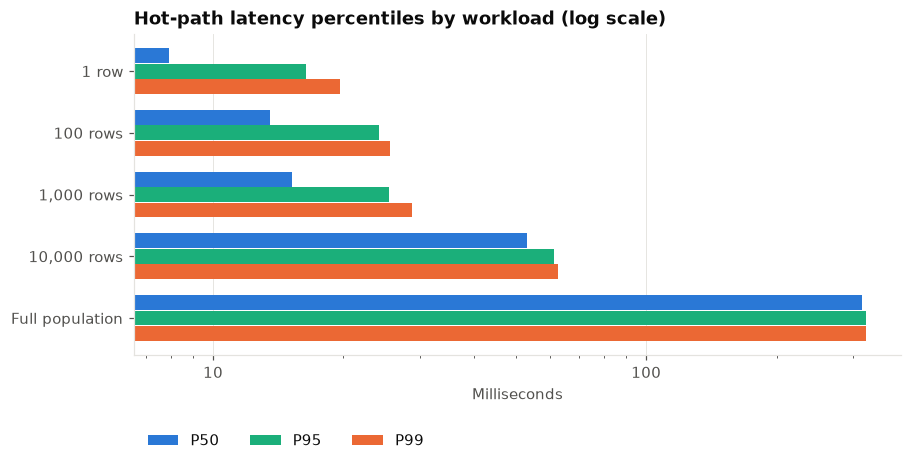

In [11]:
display(
    standard_results[
        [
            "Workload",
            "Rows",
            "Runs",
            "Hot Path Mean ms",
            "Hot Path P50 ms",
            "Hot Path P90 ms",
            "Hot Path P95 ms",
            "Hot Path P99 ms",
            "Hot Path Std ms",
        ]
    ]
)
fig, ax = plt.subplots(figsize=(9, 3.8))
positions = np.arange(len(standard_results))
for offset, column, color in [
    (-0.25, "Hot Path P50 ms", CATEGORICAL[0]),
    (0, "Hot Path P95 ms", CATEGORICAL[2]),
    (0.25, "Hot Path P99 ms", CATEGORICAL[1]),
]:
    ax.barh(
        positions + offset,
        standard_results[column],
        height=0.24,
        color=color,
        label=column.replace("Hot Path ", "").replace(" ms", ""),
    )
ax.set_yticks(positions, standard_results["Workload"])
ax.invert_yaxis()
ax.set_xscale("log")
ax.set(title="Hot-path latency percentiles by workload (log scale)", xlabel="Milliseconds")
ax.xaxis.set_major_formatter(plt.FuncFormatter(compact_number))
ax.xaxis.set_minor_formatter(plt.NullFormatter())
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.2), ncol=3)
plt.show()

## 15. Throughput Analysis

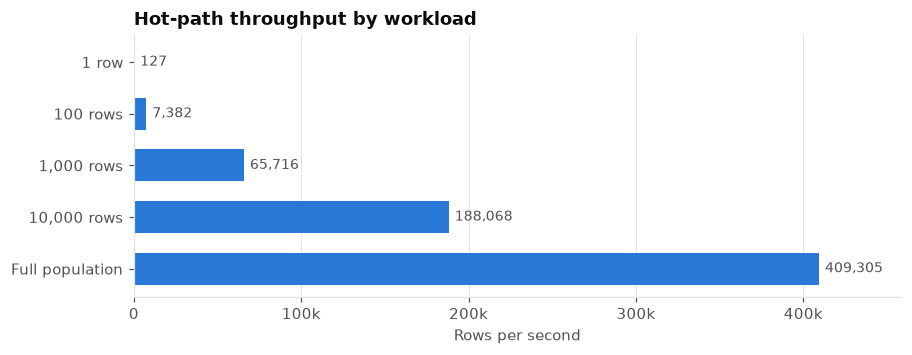

Peak throughput **409,305 rows/s** at **Full population**. Cost per 1,000 rows falls from **7900.0 ms** (single row) to **2.443 ms** (full batch), a **~3,233×** batching gain.

In [12]:
peak_thr = standard_results["Hot Path Throughput (rows/s)"].max()
peak_workload = standard_results.loc[
    standard_results["Hot Path Throughput (rows/s)"].idxmax(), "Workload"
]
unit_single = standard_results.loc[0, "Hot Path ms / 1,000 rows"]
unit_batch = standard_results.loc[4, "Hot Path ms / 1,000 rows"]
ratio_amortized = unit_single / unit_batch if unit_batch > 0 else 0.0
bar_chart(
    standard_results.set_index("Workload")["Hot Path Throughput (rows/s)"],
    sort=False,
    title="Hot-path throughput by workload",
    xlabel="Rows per second",
)
plt.show()
display(
    Markdown(
        f"Peak throughput **{peak_thr:,.0f} rows/s** at **{peak_workload}**. Cost per 1,000 rows falls from "
        f"**{unit_single:.1f} ms** (single row) to **{unit_batch:.3f} ms** (full batch), a **~{ratio_amortized:,.0f}×** batching gain."
    )
)

## 16. Repeated-Run Stability

> Times only the prediction loop (`prepared matrix → predict → inverse target`) 30 times on the same 1,000 rows; the matrix is built once outside the loop.

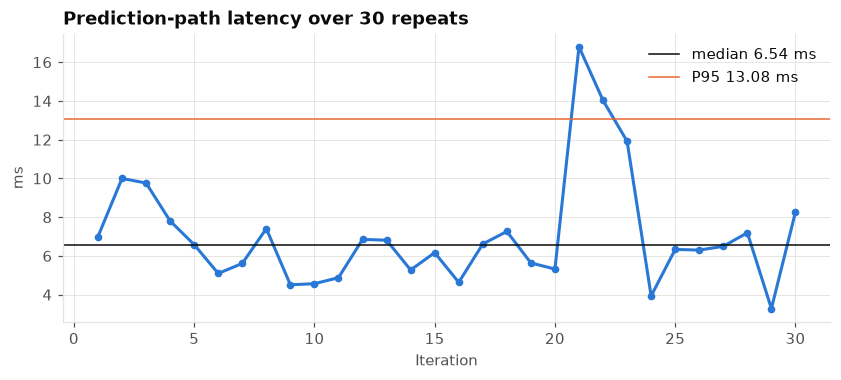

,value
Mean / std,7.077 / 2.932 ms
Min / max,3.282 / 16.796 ms
Coefficient of variation,41.44%
Assessment,STABLE (expected OS scheduling variability)


In [13]:
stability_df, stability_stats = run_repeated_stability_benchmark(
    champion, ready_population, sample_size=1000, repetitions=30, seed=BENCHMARK_RANDOM_SEED
)
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(
    stability_df["Iteration"],
    stability_df["Prediction Path Latency ms"],
    marker="o",
    markersize=4,
    color=CATEGORICAL[0],
)
ax.axhline(
    stability_stats["p50_ms"],
    color="#0b0b0b",
    linewidth=1,
    label=f"median {stability_stats['p50_ms']:.2f} ms",
)
ax.axhline(
    stability_stats["p95_ms"],
    color=CATEGORICAL[1],
    linewidth=1,
    label=f"P95 {stability_stats['p95_ms']:.2f} ms",
)
ax.set(title="Prediction-path latency over 30 repeats", xlabel="Iteration", ylabel="ms")
ax.grid(axis="y")
ax.legend(loc="upper right")
plt.show()
display(
    pd.Series(
        {
            "Mean / std": f"{stability_stats['mean_ms']:.3f} / {stability_stats['std_ms']:.3f} ms",
            "Min / max": f"{stability_stats['min_ms']:.3f} / {stability_stats['max_ms']:.3f} ms",
            "Coefficient of variation": f"{stability_stats['coefficient_of_variation_pct']:.2f}%",
            "Assessment": (
                "STABLE (expected OS scheduling variability)"
                if stability_stats["coefficient_of_variation_pct"] < 100.0
                else "UNSTABLE"
            ),
        },
        name="value",
    ).to_frame()
)

## 17. Robustness Inputs

> **Why:** unseen wards/sources, boundary areas and missing values must not crash or reorder outputs.

In [14]:
robustness_results = run_robustness_benchmark(champion, ready_population)
display(robustness_results)
assert (robustness_results["Status"] == "PASS").all(), "All edge cases must be handled safely"

,Case ID,Description,Predicted Monthly Rent,Latency ms,Status,Notes
0,missing_ward,Missing ward_current (null/None),5398601.0,8.81,PASS,"Order preserved, finite positive prediction"
1,missing_district,Missing district_text_extracted (null/None),3882970.0,8.40,PASS,"Order preserved, finite positive prediction"
2,unseen_ward,Out-of-vocabulary ward name,5163897.0,6.29,PASS,"Order preserved, finite positive prediction"
3,unseen_district,Out-of-vocabulary district name,3705607.0,7.13,PASS,"Order preserved, finite positive prediction"
4,unseen_source,Out-of-vocabulary crawler source_code,5418802.0,6.22,PASS,"Order preserved, finite positive prediction"
5,small_valid_area_example,Representative boundary-like small area exampl...,2163864.0,7.21,PASS,"Order preserved, finite positive prediction"
6,large_valid_area_example,Representative boundary-like large area exampl...,3539540.0,7.55,PASS,"Order preserved, finite positive prediction"
7,mixed_missing_cats,All categorical columns missing concurrently,3973377.0,5.87,PASS,"Order preserved, finite positive prediction"


## 18. Optional Concurrency Benchmark

> More threads raise total throughput but also per-request latency (shared CPU, scheduling and nested parallelism).

,Workers,Total Requests,Batch Size per Request,Total Rows Served,Wall Clock ms,Request P50 ms,Request P95 ms,Aggregate Throughput (rows/s),RSS Delta MB
0,1,12,1000,12000,56.13,4.50,5.64,213785.2,0.29
1,2,12,1000,12000,53.19,8.15,11.04,225625.9,0.32
2,4,12,1000,12000,33.33,8.95,11.95,359999.1,0.68


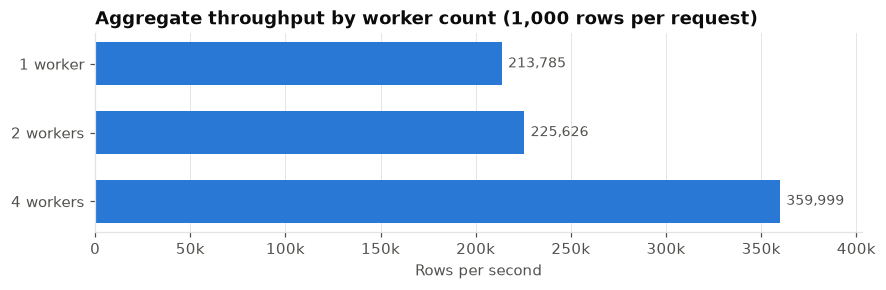

In [15]:
concurrency_results = run_concurrency_benchmark(
    champion,
    ready_population,
    batch_size=1000,
    workers_list=(1, 2, 4),
    total_requests=12,
    seed=BENCHMARK_RANDOM_SEED,
)
display(concurrency_results)
bar_chart(
    concurrency_results.set_index(
        concurrency_results["Workers"].map(lambda w: f"{w} worker" + ("s" if w > 1 else ""))
    )["Aggregate Throughput (rows/s)"],
    sort=False,
    title="Aggregate throughput by worker count (1,000 rows per request)",
    xlabel="Rows per second",
)
plt.show()

## 19. Persist Benchmark Artifacts

**Tagged `skip-execution`** so a normal run stays read-only; run it manually to record a benchmark run.

In [16]:
timestamp_now = datetime.now(timezone.utc)
perf_run_id = make_performance_run_id(
    champion.metadata["model_id"], env_info["environment_fingerprint"], timestamp_now
)
summary_payload = {
    "run_id": perf_run_id,
    "model_id": champion.metadata["model_id"],
    "timestamp": timestamp_now.isoformat(),
    "environment_fingerprint": env_info["environment_fingerprint"],
    "ready_population_rows": len(ready_population),
    "single_row_p50_ms": float(standard_results.loc[0, "Hot Path P50 ms"]),
    "full_batch_throughput_rows_sec": float(
        standard_results.loc[4, "Hot Path Throughput (rows/s)"]
    ),
    "stability_cv_pct": stability_stats["coefficient_of_variation_pct"],
    "robustness_pass": bool((robustness_results["Status"] == "PASS").all()),
}
artifacts_payload = {
    "environment": env_info,
    "artifact_metadata": champion.metadata,
    "base_results": base_results,
    "standard_results": standard_results,
    "advanced_results": scaling_results,
    "stage_breakdown": stage_breakdown,
    "memory_results": mem_stability,
    "robustness_results": robustness_results,
    "concurrency_results": concurrency_results,
    "summary": summary_payload,
}
persisted_dir = persist_performance_run(PERF_OUTPUT_ROOT, perf_run_id, artifacts_payload)
manifest_data = json.loads((persisted_dir / "manifest.json").read_text(encoding="utf-8"))
display(Markdown(f"Run `{perf_run_id}` persisted to `{persisted_dir.relative_to(PROJECT_ROOT)}`."))
display(
    pd.DataFrame(
        [{"File": name, "SHA-256": digest} for name, digest in manifest_data["files"].items()]
    )
)

Run `perf-4c203abb3b62-b81afa87-20261008T084541Z` persisted to `data/modeling/performance_benchmark/runs/perf-4c203abb3b62-b81afa87-20261008T084541Z`.

,File,SHA-256
0,environment.json,20ea12affbb6c5feb018951112af2c301eb39911be741d...
1,artifact_metadata.json,5e39979b4e216d2910cfc3e99d9387db6165ab8b1d19a5...
2,summary.json,41619686432a115bb8ec76338246075d62df292706f994...
3,base_results.csv,35fe079e84736866fafb676f77e5a6ca83fdcf5c70b927...
4,standard_results.csv,1cddd5fa534b03ad2db2141f9d9843500cc253a59166e8...
5,advanced_results.csv,7649efea9832d210bed66269f761af620f0f28a5838388...
6,stage_breakdown.csv,be46e09172a70a4edb8534950059c6e6445b6389a275af...
7,memory_results.csv,1336c736a92e04403cfd13c9cb00593090507006dcfe66...
8,robustness_results.csv,dfa62a1da5151934c0093567c52b29e1e4f0e51cbfdfbb...
9,concurrency_results.csv,0812eec06f38f2f725d89e38bfc5fc7e6c267fd5ff50ab...


## 20. Performance Baseline Summary

In [17]:
final_performance_rows = [
    {
        "Scope": "Hot path (warm)",
        "Workload": row["Workload"],
        "P50": f"{row['Hot Path P50 ms']:.2f} ms",
        "P95": f"{row['Hot Path P95 ms']:.2f} ms",
        "P99": f"{row['Hot Path P99 ms']:.2f} ms",
        "Throughput": f"{row['Hot Path Throughput (rows/s)']:,.0f} rows/s",
        "RSS delta": f"{row['RSS Delta MB']:+.2f} MB",
    }
    for _, row in standard_results.iterrows()
]
final_performance_rows += [
    {
        "Scope": "Cold model load",
        "Workload": row["Workload"],
        "P50": f"{row['Cold Model Load P50 ms']:.2f} ms",
        "P95": "N/A",
        "P99": "N/A",
        "Throughput": "N/A",
        "RSS delta": "N/A",
    }
    for _, row in cold_warm_results.iterrows()
    if row["Rows"] in (1, 10000)
]
final_performance_rows.append(
    {
        "Scope": "Full pipeline (7 stages)",
        "Workload": "10,000 rows",
        "P50": f"{full_pipeline_instrumented_median:.2f} ms (sum)",
        "P95": "N/A",
        "P99": "N/A",
        "Throughput": f"{compute_throughput(10000, full_pipeline_instrumented_median):,.0f} rows/s",
        "RSS delta": "N/A",
    }
)
display(pd.DataFrame(final_performance_rows))

quality_ctx = get_champion_quality_context(BENCHMARK_DIR)
if quality_ctx:
    display(
        Markdown(
            f"**Model quality context (from Notebook 04, not part of performance scoring):** TEST MAE "
            f"{quality_ctx['test_mae']:,.0f} VND, MedianAE {quality_ctx['test_median_ae']:,.0f} VND, R² {quality_ctx['test_r2']:.3f}; "
            f"baseline {quality_ctx['baseline_model']} MAE {quality_ctx['baseline_mae']:,.0f} VND."
        )
    )

,Scope,Workload,P50,P95,P99,Throughput,RSS delta
0,Hot path (warm),1 row,7.90 ms,16.37 ms,19.66 ms,127 rows/s,+0.11 MB
1,Hot path (warm),100 rows,13.55 ms,24.20 ms,25.67 ms,"7,382 rows/s",+0.02 MB
2,Hot path (warm),"1,000 rows",15.22 ms,25.50 ms,28.86 ms,"65,716 rows/s",+0.00 MB
3,Hot path (warm),"10,000 rows",53.17 ms,61.11 ms,62.62 ms,"188,068 rows/s",+0.00 MB
4,Hot path (warm),Full population,315.44 ms,321.59 ms,322.14 ms,"409,305 rows/s",+0.01 MB
5,Cold model load,1 row,14.26 ms,N/A,N/A,N/A,N/A
6,Cold model load,"10,000 rows",47.12 ms,N/A,N/A,N/A,N/A
7,Full pipeline (7 stages),"10,000 rows",112.31 ms (sum),N/A,N/A,"89,035 rows/s",N/A


**Model quality context (from Notebook 04, not part of performance scoring):** TEST MAE 916,127 VND, MedianAE 623,718 VND, R² 0.205; baseline Hierarchical Segment Median MAE 979,095 VND.

## 21. Engineering Readiness

In [18]:
scorecard = build_performance_scorecard(
    base_results,
    standard_results,
    {
        "robustness_pass": bool((robustness_results["Status"] == "PASS").all()),
        "stability_cv": stability_stats["coefficient_of_variation_pct"],
    },
)
display(scorecard)
full_batch_rows = int(standard_results.loc[4, "Rows"])
display(
    Markdown(
        f"""
### Verdict: `IN-PROCESS PERFORMANCE BASELINE = ESTABLISHED`

**Key findings**

- Champion `{champion.metadata['model_id']}` loaded with a matching SHA-256.
- Warm single-row scoring: **{single_p50:.2f} ms** median (in-process only; no network or HTTP overhead).
- Full population ({full_batch_rows:,} listings) scores in **{batch_p50:.1f} ms** (**{batch_thr:,.0f} rows/s**); batching cuts cost per row ~{ratio_amortized:,.0f}×.
- No material persistent RSS growth was observed across the measured repeated-run window.
- Unseen wards, districts and sources, boundary areas and missing values are handled without crashes or reordering.

**Next step:** with runtime expectations quantified, the model can move to shadow monitoring behind a serving API.
"""
    )
)

,Benchmark Level,Scope,Status,Evidence
0,BASE,"Artifact load, single-row, basic batch, memory...",COMPLETE,3 workloads verified; all predictions finite &...
1,STANDARD,"Hot inference path: P50/P95/P99 latency, batch...",COMPLETE,5 workload sizes measured with repeated high-r...
2,ADVANCED,"Full inference pipeline stages, cold model loa...",COMPLETE,8 edge cases handled without crash; memory & l...
3,OVERALL,RoomBeacon Champion In-Process Performance Bas...,IN-PROCESS PERFORMANCE BASELINE = ESTABLISHED,Empirical runtime profile established on froze...



### Verdict: `IN-PROCESS PERFORMANCE BASELINE = ESTABLISHED`

**Key findings**

- Champion `roombeacon-price-lgbm-f4-raw-4c203abb3b62` loaded with a matching SHA-256.
- Warm single-row scoring: **7.90 ms** median (in-process only; no network or HTTP overhead).
- Full population (129,112 listings) scores in **315.4 ms** (**409,305 rows/s**); batching cuts cost per row ~3,233×.
- No material persistent RSS growth was observed across the measured repeated-run window.
- Unseen wards, districts and sources, boundary areas and missing values are handled without crashes or reordering.

**Next step:** with runtime expectations quantified, the model can move to shadow monitoring behind a serving API.
